# ch224 — Monte Carlo Integration

Classical quadrature rules fail badly in high dimensions: a grid with N points per axis needs N^D points in D dimensions. For D=10 and N=100, that is 10^20 evaluations — impossible.

Monte Carlo integration scales as **1/sqrt(n)** regardless of dimension. It trades deterministic accuracy for statistical approximation, and wins decisively when D > 5.

*(This connects to Part VIII — Probability and random sampling)*

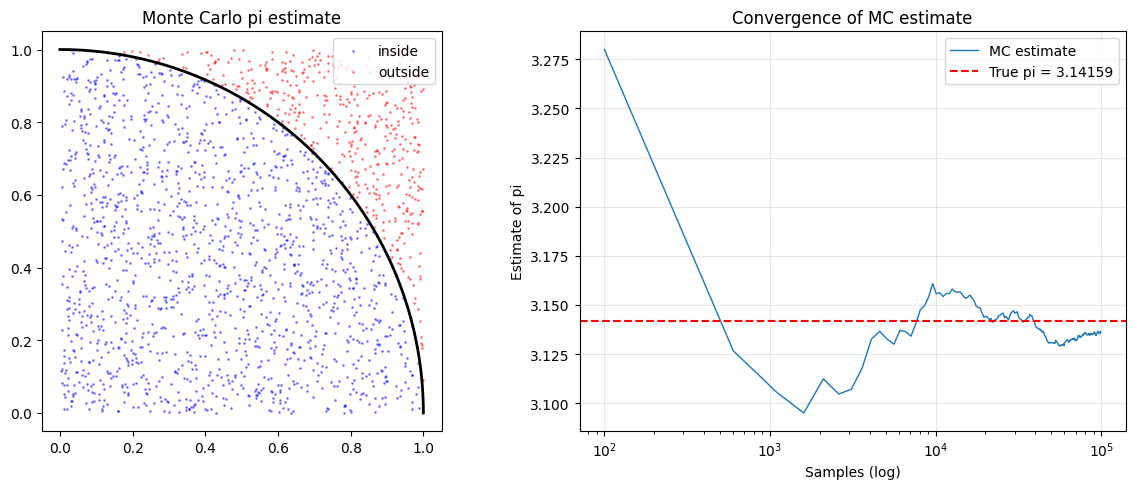

MC estimate of pi (100000 samples): 3.137600
True pi:                                3.141593


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Classic demo: estimate pi by sampling the unit square
# Points inside the quarter-circle (x^2 + y^2 < 1) have proportion pi/4

n_samples = 100_000
x = np.random.uniform(0, 1, n_samples)
y = np.random.uniform(0, 1, n_samples)
inside = x**2 + y**2 < 1.0

pi_estimates = []
for n in range(100, n_samples+1, 500):
    pi_est = 4 * np.sum(inside[:n]) / n
    pi_estimates.append((n, pi_est))

ns, pis = zip(*pi_estimates)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Scatter: first 2000 points
axes[0].scatter(x[:2000][inside[:2000]], y[:2000][inside[:2000]],
                s=1, color='blue', alpha=0.4, label='inside')
axes[0].scatter(x[:2000][~inside[:2000]], y[:2000][~inside[:2000]],
                s=1, color='red', alpha=0.4, label='outside')
theta = np.linspace(0, np.pi/2, 100)
axes[0].plot(np.cos(theta), np.sin(theta), 'k', lw=2)
axes[0].set_aspect('equal'); axes[0].legend(); axes[0].set_title('Monte Carlo pi estimate')

axes[1].semilogx(ns, pis, lw=1, label='MC estimate')
axes[1].axhline(np.pi, color='red', ls='--', label=f'True pi = {np.pi:.5f}')
axes[1].set_xlabel('Samples (log)'); axes[1].set_ylabel('Estimate of pi')
axes[1].set_title('Convergence of MC estimate'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('ch224_mc_pi.png', dpi=100); plt.show()
print(f"MC estimate of pi ({n_samples} samples): {4*np.sum(inside)/n_samples:.6f}")
print(f"True pi:                                {np.pi:.6f}")


## Convergence Rate

The standard error of a Monte Carlo estimate with n samples is:

```
SE = sigma / sqrt(n)
```

Where sigma is the standard deviation of the integrand. Halving the error requires 4x more samples — regardless of the number of dimensions.

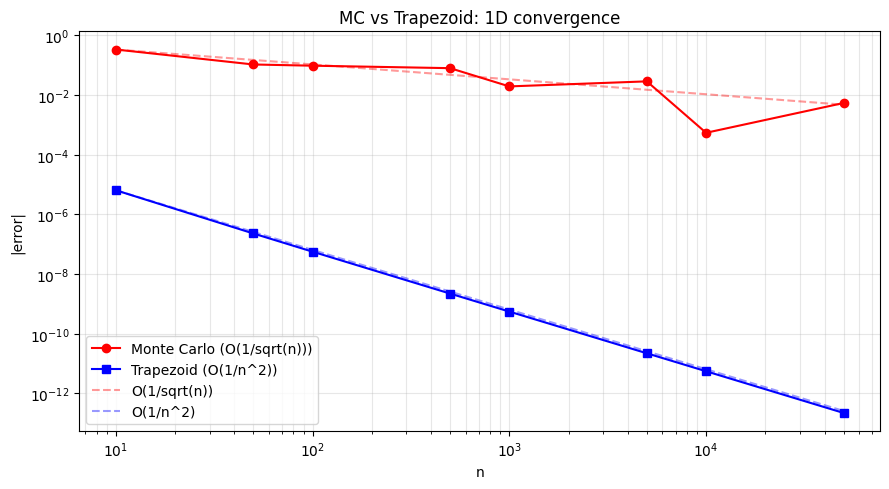

In [2]:
# Compare MC vs Trapezoid convergence in 1D
from scipy.integrate import trapezoid as trap_scipy

f = lambda x: np.exp(-x**2)
a, b = 0, 3
exact = 0.8862073482595214  # erf(3)*sqrt(pi)/2

n_vals = [10, 50, 100, 500, 1000, 5000, 10000, 50000]
mc_errors, trap_errors = [], []

for n in n_vals:
    # Monte Carlo
    samples = np.random.uniform(a, b, n)
    mc_val = (b - a) * np.mean(f(samples))
    mc_errors.append(abs(mc_val - exact))

    # Trapezoid
    x_trap = np.linspace(a, b, n)
    trap_val = trap_scipy(f(x_trap), x_trap)
    trap_errors.append(abs(trap_val - exact))

plt.figure(figsize=(9, 5))
plt.loglog(n_vals, mc_errors, 'ro-', label='Monte Carlo (O(1/sqrt(n)))')
plt.loglog(n_vals, trap_errors, 'bs-', label='Trapezoid (O(1/n^2))')
# Reference lines
ns = np.array(n_vals)
plt.loglog(ns, mc_errors[0]*np.sqrt(n_vals[0]/ns), 'r--', alpha=0.4, label='O(1/sqrt(n))')
plt.loglog(ns, trap_errors[0]*(n_vals[0]/ns)**2, 'b--', alpha=0.4, label='O(1/n^2)')
plt.xlabel('n'); plt.ylabel('|error|')
plt.title('MC vs Trapezoid: 1D convergence')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('ch224_convergence.png', dpi=100); plt.show()


## High-Dimensional Integration — Where MC Wins

Compute the volume of a d-dimensional unit sphere. Classical grids require exponential samples; MC requires only O(1/epsilon^2).

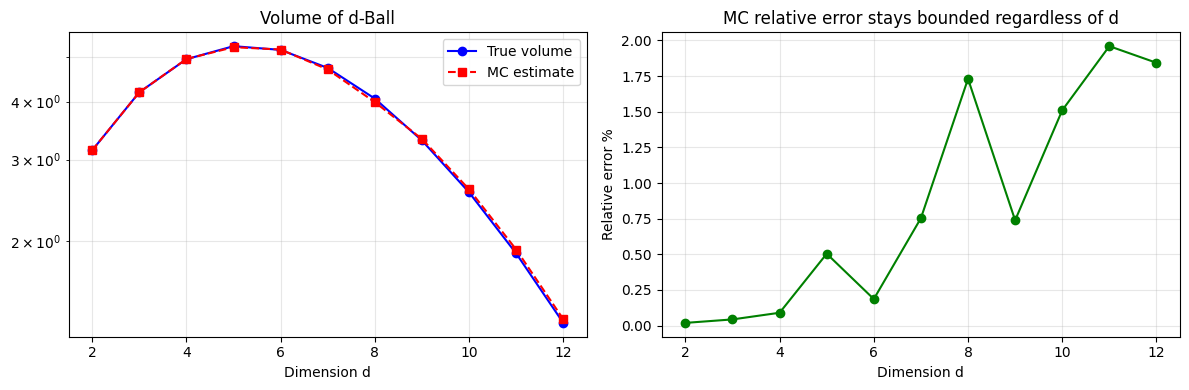

In [3]:
# Volume of d-dimensional unit ball using Monte Carlo
# V_d = pi^(d/2) / Gamma(d/2 + 1)
from math import gamma, pi as PI

def mc_volume(d, n=500_000):
    points = np.random.uniform(-1, 1, (n, d))
    inside = np.sum(points**2, axis=1) < 1.0
    return (2**d) * np.mean(inside)  # (2^d = volume of containing hypercube)

def exact_volume(d):
    return PI**(d/2) / gamma(d/2 + 1)

dims = list(range(2, 13))
mc_vols = [mc_volume(d) for d in dims]
true_vols = [exact_volume(d) for d in dims]
rel_errors = [abs(m - t)/t for m, t in zip(mc_vols, true_vols)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogy(dims, true_vols, 'b-o', label='True volume')
axes[0].semilogy(dims, mc_vols, 'r--s', label='MC estimate')
axes[0].set_xlabel('Dimension d'); axes[0].set_title('Volume of d-Ball')
axes[0].legend(); axes[0].grid(True, which='both', alpha=0.3)

axes[1].plot(dims, [e*100 for e in rel_errors], 'go-')
axes[1].set_xlabel('Dimension d'); axes[1].set_ylabel('Relative error %')
axes[1].set_title('MC relative error stays bounded regardless of d')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('ch224_highdim.png', dpi=100); plt.show()


## Summary

| Aspect | Quadrature | Monte Carlo |
|---|---|---|
| Convergence rate | O(h^p) — dimension-dependent | O(1/sqrt(n)) — dimension-free |
| Best for | 1D to 3D smooth functions | High-dimensional, discontinuous |
| Error type | Deterministic | Statistical (confidence intervals) |
| Parallelism | Hard | Trivially parallel |

**Forward reference:** Monte Carlo methods reappear in ch260 — Simulation Techniques within Part VIII (Probability) to sample from complex distributions.